# Import

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import squareform

from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram


import lightgbm as lgb
import xgboost as xgb

import importlib
import bootstrap
import distribution_estimation
import plotting
import model_wrapper
import performance_comparison

In [109]:
# Reload modules to pick up latest changes
importlib.reload(bootstrap)
importlib.reload(distribution_estimation)
importlib.reload(plotting)
importlib.reload(model_wrapper)
importlib.reload(performance_comparison)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *

print("Modules reloaded successfully!")


Modules reloaded successfully!


In [110]:
# # Quick diagnostic - check what's installed
# import sys
# print(f"Python: {sys.executable}")

# packages = ['pandas', 'numpy', 'matplotlib', 'scipy', 'sklearn', 'xgboost', 'shap', 'joblib', 'tqdm', 'statsmodels', 'seaborn']
# for pkg in packages:
#     try:
#         mod = __import__(pkg)
#         version = getattr(mod, '__version__', 'unknown')
#         print(f"✓ {pkg:15s} {version}")
#     except ImportError:
#         print(f"✗ {pkg:15s} NOT INSTALLED")

In [111]:
golub = pd.read_csv('data/golub.csv')
golub.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [112]:
df = golub.copy()

df["Y"] = df["cancer"].replace({
    "allB": "ALL",
    "allT": "ALL",
    "aml": "AML"
})

print(df["Y"].value_counts())

Y
ALL    47
AML    25
Name: count, dtype: int64


In [113]:
gene_cols = golub.columns[golub.columns.get_loc("cancer") + 1:]
print(len(gene_cols))
print(gene_cols[:5])

7129
Index(['AFFX-BioB-5_at', 'AFFX-BioB-M_at', 'AFFX-BioB-3_at', 'AFFX-BioC-5_at',
       'AFFX-BioC-3_at'],
      dtype='object')


# Prepare data

In [114]:
y = df['Y'].map({"ALL": 0, "AML": 1})
# y = df['cancer'].map({"allB": 0, "allT": 1, "aml": 2})

print("Class distribution:")
print(y.value_counts().sort_index())

Class distribution:
Y
0    47
1    25
Name: count, dtype: int64


In [115]:
cat_cols = ["BM.PB", "Gender", "Source"]
# X = df[cat_cols + positive_feature_list].copy()
X = df[cat_cols + gene_cols.tolist()].copy()

X[cat_cols] = X[cat_cols].astype("category")

In [116]:
# Check shapes before preprocessing
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y value counts:\n{y.value_counts()}")

# Ensure X and y have matching indices
assert len(X) == len(y), f"Length mismatch: X has {len(X)} samples, y has {len(y)} samples"
assert X.index.equals(y.index), "X and y have different indices"

print("\n✓ X and y shapes are consistent")

X shape: (72, 7132)
y shape: (72,)
y value counts:
Y
0    47
1    25
Name: count, dtype: int64

✓ X and y shapes are consistent


In [117]:
# Standardize gene columns
X_gene_standardized = df[gene_cols].copy()
scaler_genes = StandardScaler()
X_gene_standardized[gene_cols] = scaler_genes.fit_transform(X_gene_standardized[gene_cols])

# Grouping

### Clustering

In [178]:
correlation_threshold = 0.6

In [179]:
# --- Build distance matrix from absolute correlation ---
abs_corr = X_gene_standardized.corr(method='pearson').abs()
distance_matrix = 1 - abs_corr  # correlation 0.7 → distance 0.3

# Ensure symmetry and zero diagonal (numerical safety)
np.fill_diagonal(distance_matrix.values, 0)
condensed_dist = squareform(distance_matrix.values, checks=False)

# --- Hierarchical clustering with complete linkage ---
Z = linkage(condensed_dist, method='complete')

# --- Cut tree: distance threshold = 1 - correlation_threshold ---
distance_threshold = 1 - correlation_threshold  # = 0.3

labels = fcluster(Z, t=distance_threshold, criterion='distance')

# --- Build result DataFrame ---
gene_cluster_df = pd.DataFrame({
    'gene': gene_cols,
    'cluster': labels
})

# --- Verification: confirm all pairs within each cluster satisfy threshold ---
violations = 0
for cluster_id in gene_cluster_df['cluster'].unique():
    genes_in_cluster = gene_cluster_df[gene_cluster_df['cluster'] == cluster_id]['gene'].tolist()
    if len(genes_in_cluster) < 2:
        continue
    cluster_corr = abs_corr.loc[genes_in_cluster, genes_in_cluster]
    min_corr = cluster_corr.values[np.triu_indices_from(cluster_corr.values, k=1)].min()
    if min_corr < correlation_threshold:
        violations += 1
        print(f"  Cluster {cluster_id}: min pairwise correlation = {min_corr:.3f} ← VIOLATION")

print(f"Violations: {violations}")  # Should always be 0

# --- Summary stats ---
cluster_sizes = gene_cluster_df['cluster'].value_counts()
print(f"Correlation threshold:  {correlation_threshold}")
print(f"Number of clusters:     {gene_cluster_df['cluster'].nunique()}")
print(f"Mean cluster size:      {cluster_sizes.mean():.2f}")
print(f"Median cluster size:    {cluster_sizes.median():.2f}")
print(f"Max cluster size:       {cluster_sizes.max()}")
print(f"Singletons:             {(cluster_sizes == 1).sum()}")
print(f"Multi-gene clusters:    {(cluster_sizes > 1).sum()}")

Violations: 0
Correlation threshold:  0.6
Number of clusters:     3649
Mean cluster size:      1.95
Median cluster size:    1.00
Max cluster size:       60
Singletons:             2105
Multi-gene clusters:    1544


In [121]:
# # --- Optional: visualize dendrogram ---
# plt.figure(figsize=(12, 5))
# dendrogram(Z, labels=gene_cols, leaf_rotation=90, color_threshold=distance_threshold)
# plt.axhline(y=distance_threshold, color='red', linestyle='--', label=f'Cut at d={distance_threshold}')
# plt.ylabel("Distance (1 - |correlation|)")
# plt.title("Gene Clustering Dendrogram (Complete Linkage)")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [180]:
# Create dictionary to store PC1 for each cluster
cluster_pc1_dict = {}
cluster_variance_explained = {}

unique_clusters = gene_cluster_df['cluster'].unique()

for cluster_id in unique_clusters:
    # Get genes in this cluster
    genes_in_cluster = gene_cluster_df[gene_cluster_df['cluster'] == cluster_id]['gene'].tolist()
    
    # Extract data for these genes (samples x genes)
    cluster_data = X_gene_standardized[genes_in_cluster]
    
    if len(genes_in_cluster) == 1:
        # For singletons, use the gene itself as the representative
        cluster_pc1_dict[cluster_id] = cluster_data.values.flatten()
        cluster_variance_explained[cluster_id] = 1.0
    else:
        # Perform PCA
        pca = PCA(n_components=1)
        pc1 = pca.fit_transform(cluster_data)
        
        # Store first principal component (flattened to 1D array)
        cluster_pc1_dict[cluster_id] = pc1.flatten()
        cluster_variance_explained[cluster_id] = pca.explained_variance_ratio_[0]

# Create a dataframe with cluster representatives (samples x clusters)
X_cluster_representatives = pd.DataFrame(cluster_pc1_dict)
X_cluster_representatives.index = df.index

print(f"Original gene features: {len(gene_cols)}")
print(f"Cluster representatives (PC1): {X_cluster_representatives.shape[1]}")
print(f"Dimensionality reduction: {len(gene_cols)} → {X_cluster_representatives.shape[1]}")
print(f"\nVariance explained by PC1 (first 10 multi-gene clusters):")

# Show variance explained for multi-gene clusters
multi_gene_clusters = gene_cluster_df.groupby('cluster').size()
multi_gene_clusters = multi_gene_clusters[multi_gene_clusters > 1].index

for cluster_id in list(multi_gene_clusters)[:10]:
    n_genes = len(gene_cluster_df[gene_cluster_df['cluster'] == cluster_id])
    var_exp = cluster_variance_explained[cluster_id]
    print(f"  Cluster {cluster_id} ({n_genes} genes): {var_exp:.3f}")

Original gene features: 7129
Cluster representatives (PC1): 3649
Dimensionality reduction: 7129 → 3649

Variance explained by PC1 (first 10 multi-gene clusters):
  Cluster 7 (2 genes): 0.839
  Cluster 12 (2 genes): 0.827
  Cluster 21 (2 genes): 0.837
  Cluster 22 (3 genes): 0.770
  Cluster 25 (3 genes): 0.760
  Cluster 34 (2 genes): 0.842
  Cluster 35 (4 genes): 0.780
  Cluster 36 (2 genes): 0.821
  Cluster 58 (2 genes): 0.819
  Cluster 59 (2 genes): 0.801


In [181]:
# Correlation between cluster PC1 representatives
pc1_corr = X_cluster_representatives.corr()
print(f"Correlation matrix shape: {pc1_corr.shape} (clusters x clusters)")
print(f"\nMean absolute correlation: {pc1_corr.abs().values[np.triu_indices_from(pc1_corr.values, k=1)].mean():.4f}")
print(f"Max absolute correlation: {pc1_corr.abs().values[np.triu_indices_from(pc1_corr.values, k=1)].max():.4f}")

# Display the correlation matrix
pc1_corr

Correlation matrix shape: (3649, 3649) (clusters x clusters)

Mean absolute correlation: 0.1835
Max absolute correlation: 0.9765


,202,339,187,2556,2396,1514,227,1031,2551,598,...,2150,3065,3066,2667,1673,2159,905,760,180,1837
202,1.000000,0.684597,0.466686,0.407565,0.716038,0.100884,0.716664,0.511796,0.202008,0.314639,...,-0.051317,-0.029172,-0.047510,0.351047,0.369617,-0.040758,0.140025,0.290073,0.349263,-0.240146
339,0.684597,1.000000,0.543800,0.245201,0.631919,0.162678,0.662437,0.374761,0.091977,0.373051,...,-0.024858,0.030094,-0.049870,0.200183,0.299880,0.067002,0.127080,0.256065,0.307146,-0.366593
187,0.466686,0.543800,1.000000,0.262611,0.353331,0.171654,0.380430,0.278288,0.222167,0.317982,...,-0.036783,0.097265,0.003985,0.315796,0.076296,0.161466,0.301263,0.184521,0.172647,-0.093201
2556,0.407565,0.245201,0.262611,1.000000,0.173173,-0.109509,0.088024,0.395937,0.178202,0.108794,...,-0.135267,0.224332,0.157181,0.345060,0.186347,0.027007,-0.049167,0.176323,0.322443,0.016885
2396,0.716038,0.631919,0.353331,0.173173,1.000000,0.091866,0.780193,0.173061,0.041755,0.091380,...,-0.050151,-0.318644,-0.211054,0.386066,0.157688,-0.157789,-0.189941,0.224155,0.231332,-0.402509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2159,-0.040758,0.067002,0.161466,0.027007,-0.157789,0.166532,0.015108,-0.180304,0.216073,0.127799,...,-0.309742,0.182164,0.195017,0.008117,-0.150713,1.000000,0.061635,-0.245409,0.046119,0.108225
905,0.140025,0.127080,0.301263,-0.049167,-0.189941,0.077713,0.101720,0.367171,0.217971,0.271674,...,0.213165,0.042927,-0.058594,-0.027967,0.221529,0.061635,1.000000,0.250120,0.139799,0.133787
760,0.290073,0.256065,0.184521,0.176323,0.224155,0.094592,0.218575,0.444542,0.029590,0.080075,...,0.285740,-0.077041,-0.040601,-0.051355,0.220404,-0.245409,0.250120,1.000000,0.217840,0.165148
180,0.349263,0.307146,0.172647,0.322443,0.231332,0.107599,0.288838,0.271765,0.036500,0.383050,...,0.079560,0.182021,0.025224,0.065066,0.183714,0.046119,0.139799,0.217840,1.000000,-0.002527


In [182]:
# Create X_grouped with categorical columns and cluster PC1 representatives
X_grouped = pd.concat([df[cat_cols], X_cluster_representatives], axis=1)
# 
# Convert all column names to strings (required by sklearn)
X_grouped.columns = X_grouped.columns.astype(str)

X_grouped[cat_cols] = X_grouped[cat_cols].astype("category")

print(f"X_grouped shape: {X_grouped.shape}")
print(f"  Categorical features: {len(cat_cols)}")
print(f"  Cluster PC1 features: {X_cluster_representatives.shape[1]}")
print(f"  Total features: {X_grouped.shape[1]}")
print(f"\nColumn names preview:")
print(f"  Cat cols: {cat_cols}")
print(f"  First 5 cluster IDs: {X_grouped.columns[len(cat_cols):len(cat_cols)+5].tolist()}")

X_grouped.head()

X_grouped shape: (72, 3652)
  Categorical features: 3
  Cluster PC1 features: 3649
  Total features: 3652

Column names preview:
  Cat cols: ['BM.PB', 'Gender', 'Source']
  First 5 cluster IDs: ['202', '339', '187', '2556', '2396']


,BM.PB,Gender,Source,202,339,187,2556,2396,1514,227,...,2150,3065,3066,2667,1673,2159,905,760,180,1837
0,BM,F,DFCI,-1.445046,0.530728,0.626886,1.623370,1.862281,-1.865725,-1.116311,...,1.307292,1.166166,1.392864,0.727056,0.684570,-1.151602,-0.809506,1.819697,1.465519,1.402262
1,BM,F,DFCI,1.234082,-0.090378,2.312457,1.661330,-1.959609,1.780633,-2.071500,...,-1.008454,1.697821,-0.147055,1.613636,-0.331330,-0.341011,-1.266112,-0.391112,-0.274182,-0.164323
2,BM,F,DFCI,0.828241,0.965968,0.169938,0.853734,0.396799,0.417332,0.277705,...,0.251842,-0.316676,-0.953008,-1.855094,-1.644238,1.413930,0.283765,1.005744,2.542607,-0.928367
3,BM,M,DFCI,1.747746,1.086567,-0.750589,0.331499,5.491362,-0.619970,1.835129,...,3.063122,-0.970862,0.114900,1.183157,0.478503,-0.821789,-0.228265,-0.707593,0.425806,-1.250864
4,BM,F,DFCI,-2.310666,-3.818550,-1.018977,-0.489096,-2.082513,-1.009252,-0.787923,...,0.409610,-1.847431,-1.791383,-1.696016,-1.106975,-0.828866,-0.204389,0.116422,-0.765827,-0.561162


In [183]:
# Create lookup function and reference for genes in each cluster
def get_genes_in_cluster(cluster_id):
    """Return list of genes in the specified cluster."""
    genes = gene_cluster_df[gene_cluster_df['cluster'] == cluster_id]['gene'].tolist()
    return genes

# Create a dictionary for easy lookup
cluster_to_genes = gene_cluster_df.groupby('cluster')['gene'].apply(list).to_dict()

# Display function to show cluster details
def show_cluster_info(cluster_id):
    """Display detailed information about a cluster."""
    genes = cluster_to_genes[cluster_id]
    n_genes = len(genes)
    var_exp = cluster_variance_explained.get(cluster_id, 'N/A')
    
    print(f"Cluster {cluster_id}:")
    print(f"  Number of genes: {n_genes}")
    print(f"  Variance explained by PC1: {var_exp}")
    print(f"  Genes: {genes}")
    return genes

In [184]:
print("=" * 80)
print("CLUSTER-TO-GENE MAPPING REFERENCE")
print("=" * 80)
print(f"\nTotal clusters: {len(cluster_to_genes)}")
print(f"\nCluster size statistics:")
cluster_sizes = gene_cluster_df.groupby('cluster').size()
print(f"  Min: {cluster_sizes.min()}")
print(f"  Max: {cluster_sizes.max()}")
print(f"  Mean: {cluster_sizes.mean():.2f}")
print(f"  Median: {cluster_sizes.median():.2f}")

# Show the largest clusters
print(f"\n{'='*80}")
print("LARGEST CLUSTERS (Top 5)")
print(f"{'='*80}")
largest_clusters = cluster_sizes.nlargest(5).index

for cluster_id in largest_clusters:
    genes = cluster_to_genes[cluster_id]
    var_exp = cluster_variance_explained.get(cluster_id, 'N/A')
    print(f"\nCluster {cluster_id}: {len(genes)} genes, Var explained: {var_exp:.4f}")
    print(f"  Genes: {', '.join(genes[:10])}{'...' if len(genes) > 10 else ''}")

CLUSTER-TO-GENE MAPPING REFERENCE

Total clusters: 3649

Cluster size statistics:
  Min: 1
  Max: 60
  Mean: 1.95
  Median: 1.00

LARGEST CLUSTERS (Top 5)

Cluster 658: 60 genes, Var explained: 0.8036
  Genes: AC000062_at, D13264_at, D38503_at, D42072_at, D50582_at, D86980_at, J04156_at, L07949_at, L21934_at, L40396_at...

Cluster 700: 52 genes, Var explained: 0.7790
  Genes: AFFX-LysX-5_at, AB000114_at, AB000220_at, AC000066_at, D12625_at, D14823_at, D38462_at, J04970_at, J05401_at, L07590_at...

Cluster 498: 50 genes, Var explained: 0.7671
  Genes: D13168_at, D14497_at, D37965_at, D78333_at, K02215_at, L19778_at, L34409_at, M14648_at, M25393_at, M30773_at...

Cluster 506: 36 genes, Var explained: 0.7923
  Genes: D14822_at, D21851_at, L25441_at, L27071_at, L31529_at, M62397_at, U18985_at, U26712_at, U39231_at, U55853_at...

Cluster 673: 33 genes, Var explained: 0.7556
  Genes: D13644_at, D29810_at, D49488_at, D49958_at, D76435_at, L02840_at, L19593_at, M16961_at, S82592_at, U17033_at.

### Prepare data for linear models

In [127]:
# cat_cols = ["BM.PB", "Gender", "Source"]#, "tissue.mf"]
# num_cols = [col for col in X_grouped.columns if col not in cat_cols]

# cat_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
#     ('encoder', OneHotEncoder(drop='first', sparse_output=False,
#                               handle_unknown='ignore'))
# ])

# num_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),   # safety net for any numeric NaN
#     ('scaler',  StandardScaler())
# ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', cat_transformer, cat_cols),
#         ('num', num_transformer, num_cols)
#     ],
#     verbose_feature_names_out=False
# )

# # Fit and transform
# X_preprocessed = pd.DataFrame(
#     preprocessor.fit_transform(X_grouped),
#     columns=preprocessor.get_feature_names_out(),
#     index=X_grouped.index
# )

# TreeSHAP Kernel Distribution Estimation 

See `model_wrapper.py` for the flexible ModelWrapper interface.

In [128]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

## Model Wrapper

In [129]:
## Example: Using different models with the SHAP distribution algorithm

# # Example 1: Random Forest (sklearn)
# rf_wrapper = create_model_wrapper(
#     "sklearn",
#     model_class=RandomForestClassifier,
#     model_params={"n_estimators": 100, "random_state": 42, "max_depth": 10},
#     use_tree_explainer=True
# )

# # Example 2: Neural Network - sklearn MLP

# mlp_wrapper = create_model_wrapper(
#     "sklearn",
#     model_class=MLPClassifier,
#     model_params={"hidden_layer_sizes": (64, 32), "random_state": 42, "max_iter": 200},
#     use_tree_explainer=False  # Use KernelExplainer for MLP
# )

## Example 3: PyTorch Neural Network
# def create_pytorch_model(input_dim, hidden_dim=64, num_classes=3):
#     import torch.nn as nn
#     return nn.Sequential(
#         nn.Linear(input_dim, hidden_dim),
#         nn.ReLU(),
#         nn.Dropout(0.2),
#         nn.Linear(hidden_dim, hidden_dim),
#         nn.ReLU(),
#         nn.Linear(hidden_dim, num_classes)
#     )

# pytorch_wrapper = create_model_wrapper(
#     "pytorch",
#     model_fn=create_pytorch_model,
#     model_params={"input_dim": X.shape[1], "hidden_dim": 64, "num_classes": 3},
#     train_params={"epochs": 50, "lr": 0.001, "batch_size": 16},
#     explainer_type="deep"  # or "gradient" or "kernel"
# )

## Example 4: Keras/TensorFlow
# def create_keras_model(input_dim, num_classes=3):
#     from tensorflow.keras import Sequential
#     from tensorflow.keras.layers import Dense, Dropout
#     model = Sequential([
#         Dense(64, activation='relu', input_dim=input_dim),
#         Dropout(0.2),
#         Dense(32, activation='relu'),
#         Dense(num_classes, activation='softmax')
#     ])
#     model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#     return model
# 
# keras_wrapper = create_model_wrapper(
#     "keras",
#     model_fn=create_keras_model,
#     model_params={"input_dim": X.shape[1], "num_classes": 3},
#     train_params={"epochs": 50, "batch_size": 16}
# )

# print("Model wrappers created successfully!")

In [130]:
# Complete example: Compare SHAP distributions across different models
# Create wrappers for different models

# models = {
#     "XGBoost": "xgboost_wrapper",
    
#     "RandomForest": create_model_wrapper(
#         "sklearn",
#         model_class=RandomForestClassifier,
#         model_params={"n_estimators": 50, "max_depth": 10, "random_state": 42, "n_jobs": 1},
#         use_tree_explainer=True
#     ),
    
#     "GradientBoosting": create_model_wrapper(
#         "sklearn",
#         model_class=GradientBoostingClassifier,
#         model_params={"n_estimators": 50, "max_depth": 5, "random_state": 42},
#         use_tree_explainer=True
#     ),
    
#     "MLP": create_model_wrapper(
#         "sklearn",
#         model_class=MLPClassifier,
#         model_params={
#             "hidden_layer_sizes": (64, 32),
#             "random_state": 42,
#             "max_iter": 200,
#             "early_stopping": True
#         },
#         use_tree_explainer=False  # Use KernelExplainer for neural networks
#     ),
# }

# print("Model wrappers created:")
# for name in models:
#     print(f"  ✓ {name}")

# To run bootstrap for a specific model:
# model_name = "RandomForest"
# boot_results = boot_multi_repeat_inference_keep_all(
#     X=X, y=y, task="multiclass",
#     model_wrapper=models[model_name],
#     n_bootstrap=20, b_model=5, zero_tol=1e-12,
#     n_jobs=6, show_progress=True, return_as="list"
# )
# 
# # Then use same distribution estimation functions
# mix_df = estimate_zero_normal_mixture(boot_results)
# feature_sq_df = estimate_feature_level_sq_mixture_gamma(boot_results, aggregate_classes=True)

## LightGBM Model

In [136]:
# LightGBM parameters (similar structure to XGBoost)
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'learning_rate': 0.1,
    'max_depth': 8,
    'num_leaves': 31,
    'min_data_in_leaf': 15,
    'min_sum_hessian_in_leaf': 1e-3,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': 42,
    'deterministic': True,
    'num_threads': 1,
}


lgb_wrapper = create_model_wrapper(
    "lightgbm",
    params=lgb_params,
    num_boost_round=150
)

print("LightGBM wrapper created!")
print("Ready to train and evaluate")

LightGBM wrapper created!
Ready to train and evaluate


In [137]:
print("Training LightGBM model...")
X_train, X_test, y_train, y_test = train_test_split(X_grouped, y, test_size=0.2, random_state=123, stratify=y)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)


Training LightGBM model...
Training set: (57, 5154)
Test set: (15, 5154)


### Screening with |SHAP|

Training LightGBM model and computing SHAP values for feature ranking...
✓ Model trained successfully
Computing SHAP values...
✓ SHAP values computed

Top 10 features by total |SHAP|:
feature  total_abs_shap
   4419       91.512509
   5102       66.539931
     26       48.652120
   3122       38.372195
   4439       31.646083
   4739       21.142513
   2600       18.967317
   4341       18.853183
   3791       15.386051
   4387       13.886473


Evaluating LightGBM performance with SHAP-based feature selection...
✓ 0.01% (1 features): Acc=0.8667, F1=0.8500, AUC(macro)=0.9800
✓ 0.05% (2 features): Acc=1.0000, F1=1.0000, AUC(macro)=1.0000
✓ 0.1% (5 features): Acc=1.0000, F1=1.0000, AUC(macro)=1.0000
✓ 0.5% (25 features): Acc=0.9333, F1=0.9206, AUC(macro)=1.0000
✓ 1% (51 features): Acc=0.9333, F1=0.9206, AUC(macro)=1.0000
✓ 5% (257 features): Acc=0.9333, F1=0.9206, AUC(macro)=1.0000
✓ 10% (515 features): Acc=0.9333, F1=0.9206, AUC(macro)=1.0000
✓ 50% (2577 features): Acc=0.9333, F1=0.9206

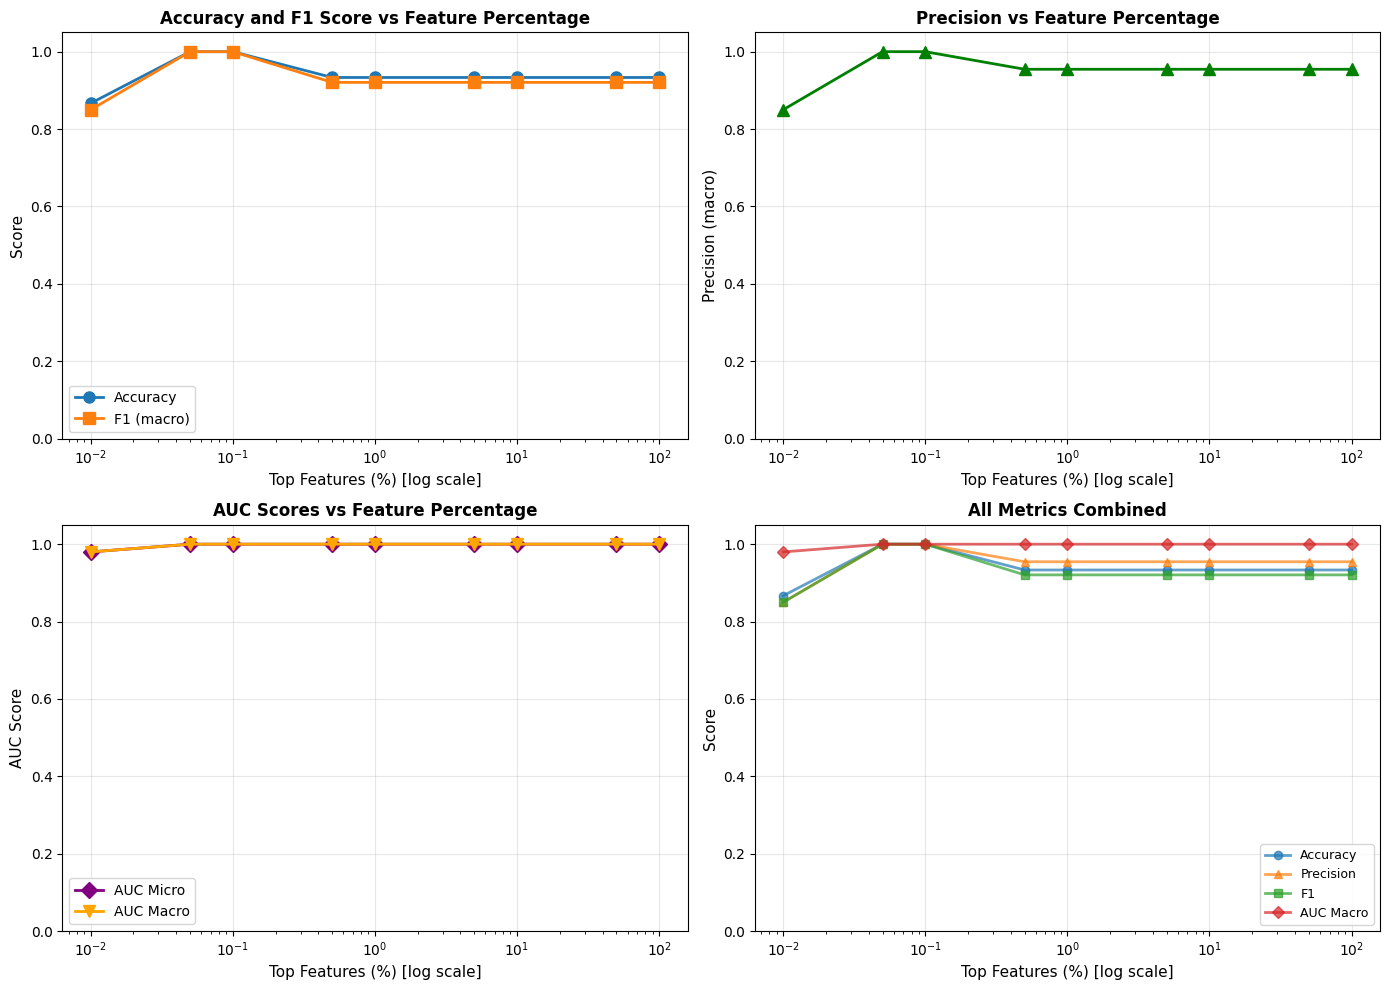


RESULTS TABLE (LightGBM SHAP-based Feature Selection):
 Percentage  N_Features  Accuracy  Precision (macro)  F1 (macro)  AUC Micro  AUC Macro
       0.01           1  0.866667           0.850000    0.850000       0.98       0.98
       0.05           2  1.000000           1.000000    1.000000       1.00       1.00
       0.10           5  1.000000           1.000000    1.000000       1.00       1.00
       0.50          25  0.933333           0.954545    0.920635       1.00       1.00
       1.00          51  0.933333           0.954545    0.920635       1.00       1.00
       5.00         257  0.933333           0.954545    0.920635       1.00       1.00
      10.00         515  0.933333           0.954545    0.920635       1.00       1.00
      50.00        2577  0.933333           0.954545    0.920635       1.00       1.00
     100.00        5154  0.933333           0.954545    0.920635       1.00       1.00

✓ LightGBM SHAP-based feature selection analysis complete!


In [138]:
# Train LightGBM model to compute SHAP-based feature rankings
print("Training LightGBM model and computing SHAP values for feature ranking...")
print("=" * 70)

# Train LightGBM model on training data
lgb_ranking_model = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.1,
    num_leaves=31,
    n_estimators=100,
    random_state=42,
    verbose=-1
)

lgb_ranking_model.fit(X_train, y_train)
print("✓ Model trained successfully")

# Compute SHAP values using LightGBM's built-in method
print("Computing SHAP values...")

# Get SHAP contributions directly from LightGBM (includes bias term as last column)
shap_contribs_lgb = lgb_ranking_model.predict(
    X_train, 
    pred_contrib=True
)

# For binary LightGBM: shape is (n_samples, n_features + 1)
# Add class axis so downstream code can keep the same reduction pattern.
n_samples = X_train.shape[0]
n_features = X_train.shape[1]

if shap_contribs_lgb.ndim == 2:
    shap_contribs_reshaped = shap_contribs_lgb[:, np.newaxis, :]
else:
    # Fallback for multiclass outputs if labels become >2 again.
    n_classes = len(lgb_ranking_model.classes_)
    shap_contribs_reshaped = shap_contribs_lgb.reshape(n_samples, n_classes, n_features + 1)

# Remove bias (last column) and sum |SHAP| across samples and classes
shap_values_only_lgb = shap_contribs_reshaped[:, :, :-1]  # Remove bias column
total_abs_shap_lgb = np.abs(shap_values_only_lgb).sum(axis=(0, 1))

print("✓ SHAP values computed")

# Create feature ranking dataframe
lgb_shap_feature_ranking = pd.DataFrame({
    'feature': X_train.columns,
    'total_abs_shap': total_abs_shap_lgb
}).sort_values('total_abs_shap', ascending=False).reset_index(drop=True)

print(f"\nTop 10 features by total |SHAP|:")
print(lgb_shap_feature_ranking.head(10).to_string(index=False))
print()

# Run performance evaluation using SHAP-based rankings
print("\n" + "=" * 70)
print("Evaluating LightGBM performance with SHAP-based feature selection...")
print("=" * 70)

lgb_shap_perf_table, lgb_shap_perf_fig = evaluate_top_features_performance(
    results_df=lgb_shap_feature_ranking,
    model_class=lgb.LGBMClassifier,
    X_full_train=X_train,
    X_full_test=X_test,
    y_train = y_train,
    y_test=y_test,
    percentages=[0.01, 0.05, 0.1, 0.5, 1,5, 10, 50, 100],
    ranking_col='total_abs_shap',  # Use SHAP sum instead of mean_A
    model_params={
        'objective': 'binary',
        'learning_rate': 0.1,
        'num_leaves': 31,
        'n_estimators': 100,
        'random_state': 42,
        'verbose': -1
    },
    log_x=True  # Enable log scale on x-axis
)

print("\n" + "=" * 70)
print("RESULTS TABLE (LightGBM SHAP-based Feature Selection):")
print("=" * 70)
print(lgb_shap_perf_table.to_string(index=False))
print("\n✓ LightGBM SHAP-based feature selection analysis complete!")

### Bootstrap

In [139]:
lgb_shap_feature_ranking['feature'].head(257)

0      4419
1      5102
2        26
3      3122
4      4439
       ... 
252    4865
253    4741
254     948
255    4715
256    5051
Name: feature, Length: 257, dtype: object

In [140]:
X_screened_lgb = X_grouped[lgb_shap_feature_ranking['feature'].head(356)]

X_train, X_test, y_train, y_test = train_test_split(X_screened_lgb, y, test_size=0.2, random_state=42, stratify=y)

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

In [141]:
lgb_boot_results = boot_multi_repeat_inference_keep_all(
    X=X_screened_lgb,  # Use preprocessed data with one-hot encoded categoricals
    y=y,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=2000,  
    b_model=1, 
    zero_tol=1e-8,
    model_wrapper=lgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

print(f"\nBootstrap complete! Generated {len(lgb_boot_results)} results.")

Bootstrap repeats: 100%|██████████| 2000/2000 [00:40<00:00, 49.95it/s]



Bootstrap complete! Generated 2000 results.


In [144]:
lgb_mix = estimate_sample_feature_distribution(lgb_boot_results)

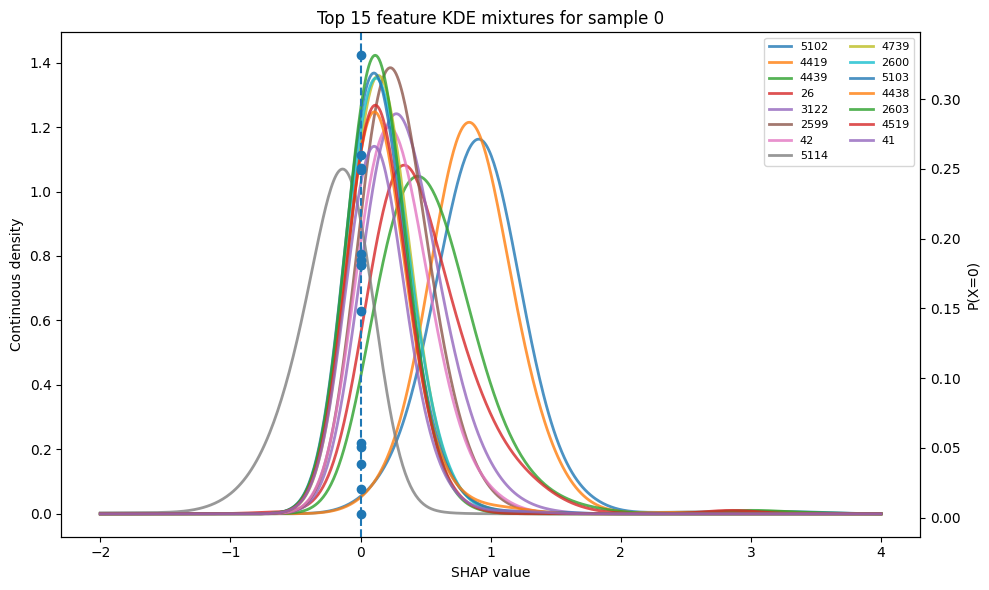

In [145]:
top_df = plot_sample_top_features_overlay(
    mix_df=lgb_mix,
    sample_id=0,
    class_id=None,  # or class index for multiclass
    top_k=15,
    rank_by="mean_abs_estimated",
    n_grid=600,
    xlim=(-2, 4)
)

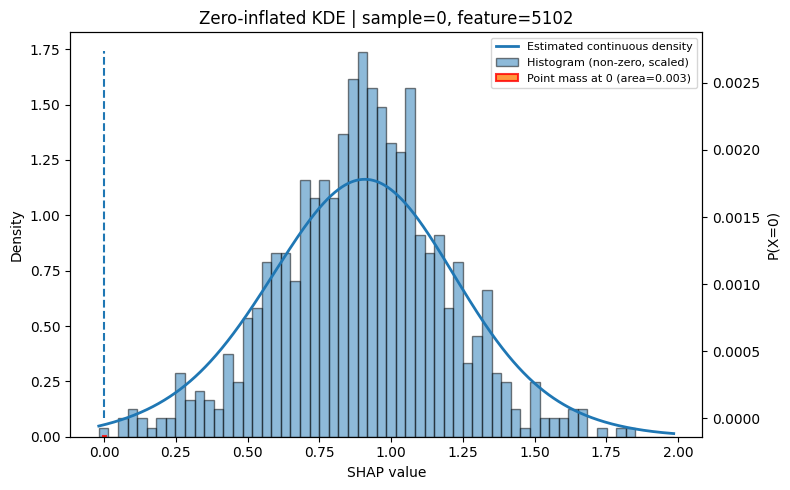

In [146]:
plot_zero_inflated_kde_with_hist(
    mix_df=lgb_mix,
    sample_id=0,
    feature="5102",
    # feature="M55150_at",
    class_id=None,  # or None for binary/regression
    boot_results=lgb_boot_results,  # list[DataFrame] or DataFrame
    bins=60,
    n_grid=800
)

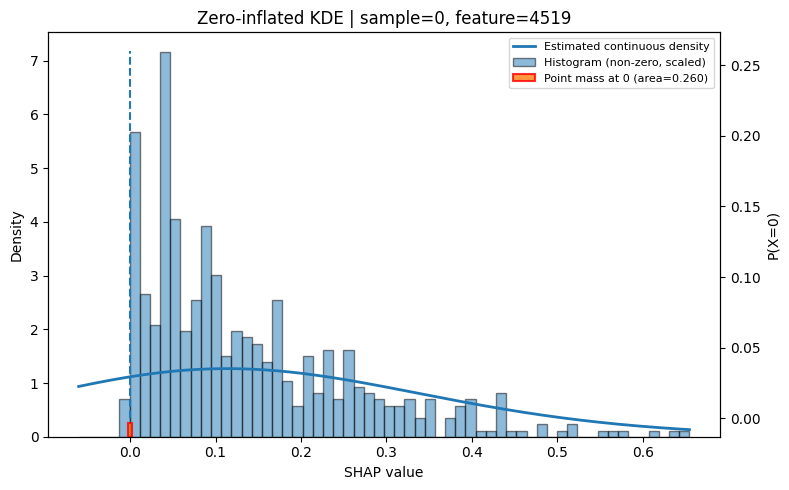

In [147]:
plot_zero_inflated_kde_with_hist(
    mix_df=lgb_mix,
    sample_id=0,
    feature="4519",
    # feature="M23197_at",
    class_id=None,  # or None for binary/regression
    boot_results=lgb_boot_results,  # list[DataFrame] or DataFrame
    bins=60,
    n_grid=800
)

In [148]:
lgb_feature_kde = estimate_feature_level_mixture(
    boot_results=lgb_boot_results,
    kernel="gaussian",
)

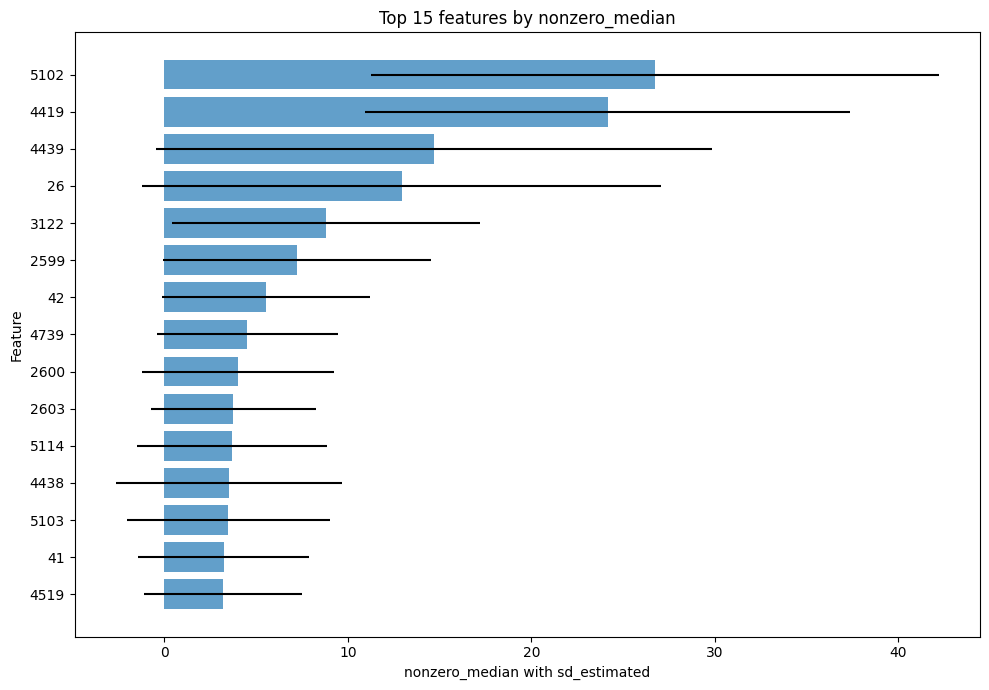

In [149]:
top_with_error = plot_top_feature_with_error(
    lgb_feature_kde,
    top_k=15,
    score_col="nonzero_median",
)

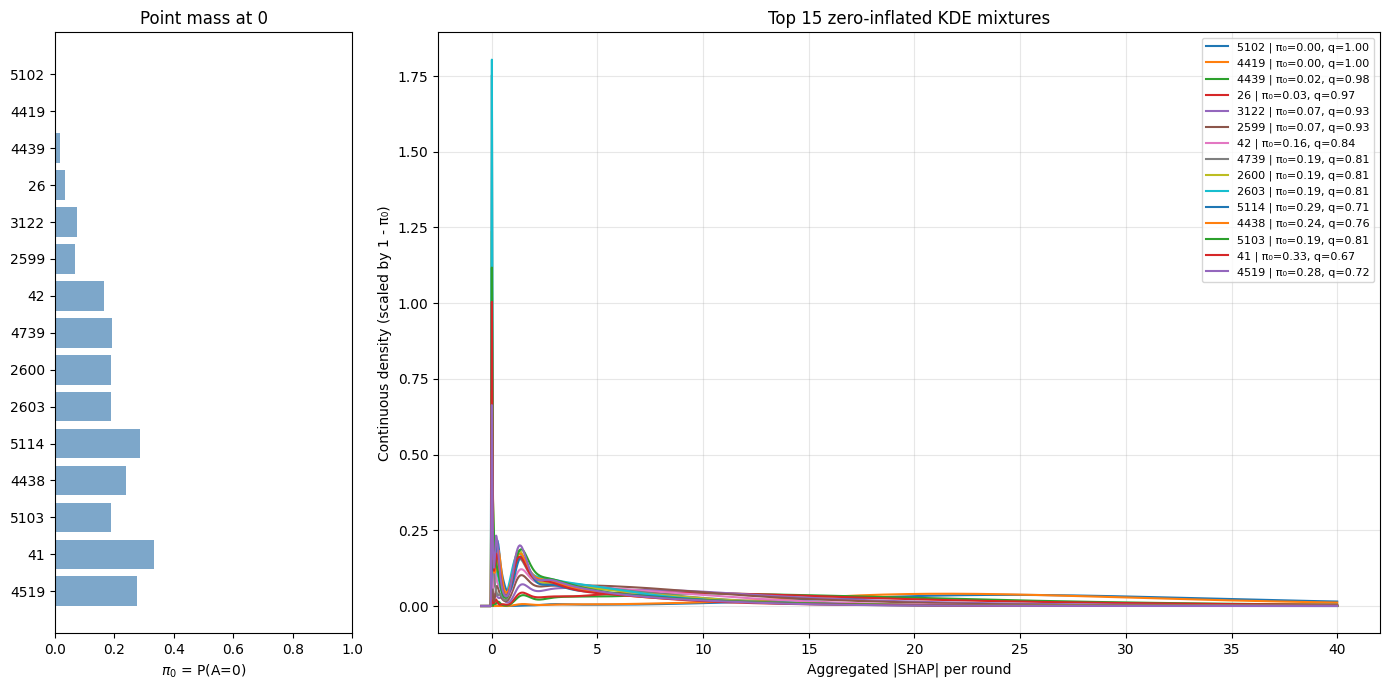

In [151]:
lgb_top = plot_top_feature_density(
    lgb_feature_kde,
    top_k=15,
    score_col="nonzero_median",
    x_min = -0.5,
    log_x=True,
    x_max=40
)

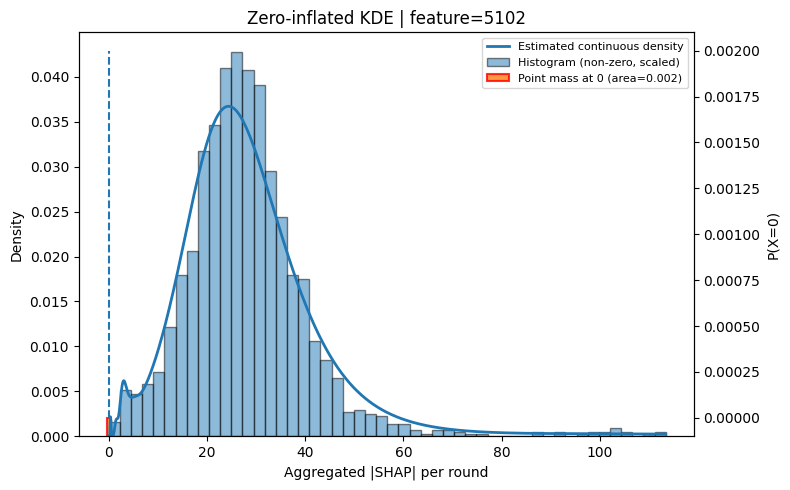

In [152]:
plot_feature_level_kde_with_hist(
    feature_level_df=lgb_feature_kde,
    boot_results=lgb_boot_results,
    feature="5102"
)

### Feature selection

In [153]:
lgb_feature_kde.head()

,feature,n_bootstrap_rounds,n_total,n_zero,n_nonzero,pi_zero,bandwidth,kernel,zero_tol,kde_model,mean_abs_estimated,mean_estimated,var_estimated,sd_estimated,p_nonzero,peak_density,nonzero_median
0,4419,2000,2000,4,1996,0.0020,0.2,gaussian,0.0,"{'pi_zero': 0.002, 'n_total': 2000, 'n_zero': ...",25.953431,25.953431,174.191545,13.198164,0.9980,0.040534,24.154065
1,5102,2000,2000,4,1996,0.0020,0.2,gaussian,0.0,"{'pi_zero': 0.002, 'n_total': 2000, 'n_zero': ...",28.848907,28.848907,238.920097,15.457040,0.9980,0.036725,26.745465
2,26,2000,2000,65,1935,0.0325,0.2,gaussian,0.0,"{'pi_zero': 0.0325, 'n_total': 2000, 'n_zero':...",15.652965,15.652965,199.908954,14.138916,0.9675,0.045891,12.940295
3,3122,2000,2000,146,1854,0.0730,0.2,gaussian,0.0,"{'pi_zero': 0.073, 'n_total': 2000, 'n_zero': ...",9.811773,9.811773,70.272352,8.382861,0.9270,0.071384,8.810140
4,4439,2000,2000,32,1968,0.0160,0.2,gaussian,0.0,"{'pi_zero': 0.016, 'n_total': 2000, 'n_zero': ...",17.558300,17.558300,229.684626,15.155350,0.9840,0.041181,14.698542


In [154]:
lgb_selected_features = lgb_feature_kde[(lgb_feature_kde['pi_zero'] < 0.05)]['feature'].tolist() 

In [155]:
lgb_selected_features

['4419', '5102', '26', '4439']

In [156]:
for cluster in lgb_selected_features:
    cluster_id = int(cluster)
    genes = cluster_to_genes.get(int(cluster_id))
    var_exp = cluster_variance_explained.get(cluster_id, 'N/A')
    print(f"\nCluster {cluster_id}: {len(genes)} genes, Var explained: {var_exp:.4f}")
    print(f"  Genes: {', '.join(genes[:10])}{'...' if len(genes) > 10 else ''}")


Cluster 4419: 2 genes, Var explained: 0.8907
  Genes: D10495_at, M23197_at

Cluster 5102: 2 genes, Var explained: 0.8914
  Genes: M92287_at, U94855_at

Cluster 26: 1 genes, Var explained: 1.0000
  Genes: U46499_at

Cluster 4439: 5 genes, Var explained: 0.8451
  Genes: M27891_at, X52056_at, X95735_at, L09209_s_at, X64072_s_at


In [157]:
X_lgb = X_grouped[lgb_selected_features]

In [158]:
# Perform stratified k-fold cross-validation
print("Running 5-fold stratified cross-validation...")
print("="*60)

lgb_cv_dataset = lgb.Dataset(X_lgb, label=y)

cv_results = lgb.cv(
    lgb_params,
    lgb_cv_dataset,
    num_boost_round=250,
    nfold=5,
    stratified=True,
    shuffle=True,
    seed=123,
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=20)
    ],
    return_cvbooster=False
)

# Extract metrics
best_iteration = len(cv_results['valid multi_logloss-mean'])
cv_logloss_mean = cv_results['valid multi_logloss-mean'][-1]
cv_logloss_std = cv_results['valid multi_logloss-stdv'][-1]

print(f"\n{'='*60}")
print(f"Cross-Validation Results:")
print(f"  Best iteration: {best_iteration}")
print(f"  Validation multi-logloss: {cv_logloss_mean:.4f} (+/- {cv_logloss_std:.4f})")
print(f"{'='*60}\n")

Running 5-fold stratified cross-validation...
Training until validation scores don't improve for 10 rounds
[20]	valid's multi_logloss: 0.128855 + 0.0831253
[40]	valid's multi_logloss: 0.063635 + 0.053471
[60]	valid's multi_logloss: 0.0400471 + 0.0278787
[80]	valid's multi_logloss: 0.0290262 + 0.0191182
[100]	valid's multi_logloss: 0.0205471 + 0.0159783
[120]	valid's multi_logloss: 0.0153586 + 0.0169362
Early stopping, best iteration is:
[129]	valid's multi_logloss: 0.0142449 + 0.0144918

Cross-Validation Results:
  Best iteration: 129
  Validation multi-logloss: 0.0142 (+/- 0.0145)



In [159]:
# Split data into train and test sets
X_lgb_train, X_lgb_test, y_lgb_train, y_lgb_test = train_test_split(
    X_lgb, y, test_size=0.2, random_state=123, stratify=y
)

Training with best_iteration from CV: 100
[20]	train's multi_logloss: 0.0797627	valid's multi_logloss: 0.0489783
[40]	train's multi_logloss: 0.019955	valid's multi_logloss: 0.012492
[60]	train's multi_logloss: 0.00565427	valid's multi_logloss: 0.00199482
[80]	train's multi_logloss: 0.00167481	valid's multi_logloss: 0.000446684
[100]	train's multi_logloss: 0.000616213	valid's multi_logloss: 0.000171652
✓ Model training complete!

Test set accuracy (OvR, class=1): 1.0000

F1 Scores (OvR):
  Binary (positive class=1): 1.0000
  Macro-average: 1.0000
  Weighted-average: 1.0000

Binary ROC AUC (OvR):
  AUC: 1.0000

Binary AUPRC (OvR):
  AP: 1.0000


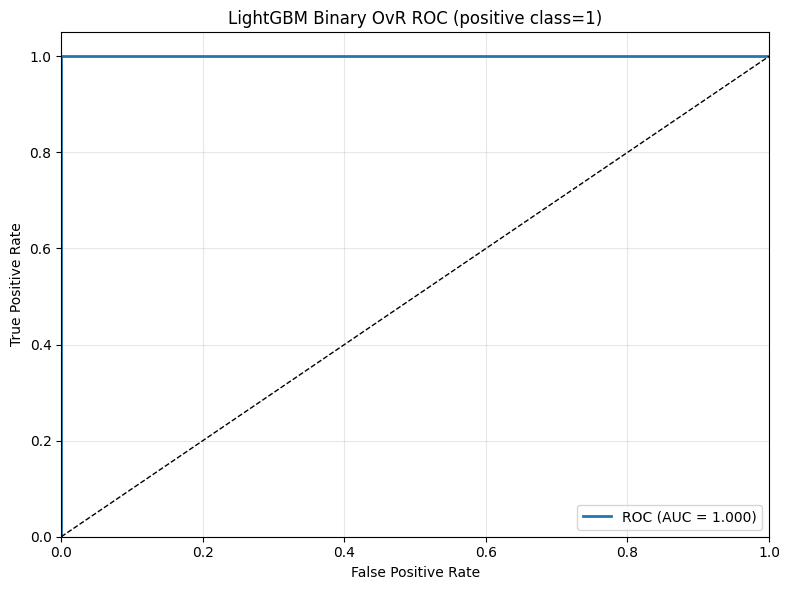

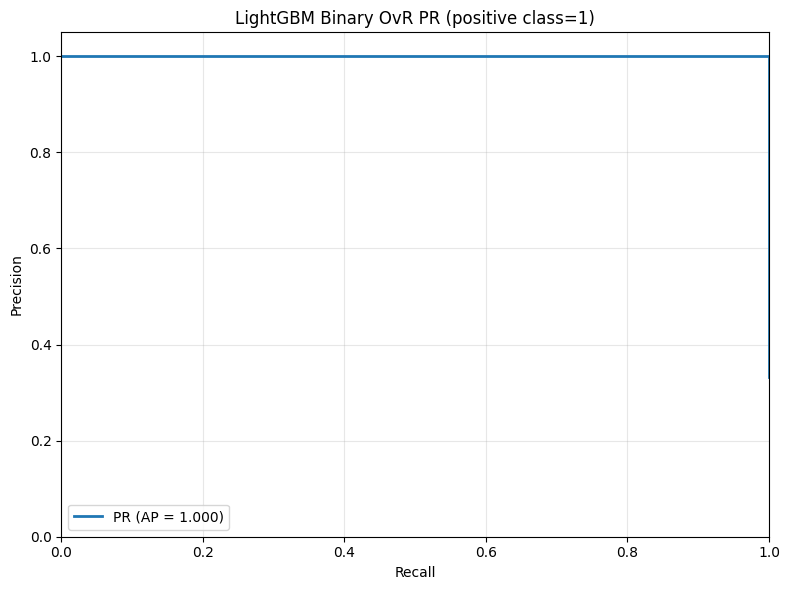


Confusion Matrix (positive class=1):
[[10  0]
 [ 0  5]]

Classification Report (binary OvR):
              precision    recall  f1-score   support

 not class 1       1.00      1.00      1.00        10
     class 1       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [ ]:
# Create LightGBM datasets
lgb_train = lgb.Dataset(X_lgb_train, label=y_lgb_train)
lgb_test = lgb.Dataset(X_lgb_test, label=y_lgb_test, reference=lgb_train)

# Train model using best iteration from CV
print(f"Training with best_iteration from CV: {best_iteration}")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=best_iteration,
    valid_sets=[lgb_train, lgb_test],
    valid_names=['train', 'valid'],
    callbacks=[lgb.log_evaluation(period=20)]
)
print("✓ Model training complete!")

# Choose positive class for binary one-vs-rest evaluation
positive_class = 1
classes_lgb = np.sort(np.unique(y_lgb_train))
if positive_class not in classes_lgb:
    raise ValueError(f"positive_class={positive_class} not found in labels: {classes_lgb}")

# Predict on test set
raw_pred = lgb_model.predict(X_lgb_test)

# Build probability for the positive class from different LightGBM output shapes
if np.ndim(raw_pred) == 1:
    # Binary objective often returns probability of positive class directly
    y_lgb_pred_proba = raw_pred.astype(float)
elif np.ndim(raw_pred) == 2:
    if raw_pred.shape[1] == 1:
        y_lgb_pred_proba = raw_pred[:, 0].astype(float)
    elif raw_pred.shape[1] == 2:
        # Binary objective returning [P(class0), P(class1)]
        y_lgb_pred_proba = raw_pred[:, 1].astype(float)
    else:
        # Multiclass output; use OvR probability for selected positive class
        pos_idx = int(np.where(classes_lgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[1]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_lgb_pred_proba = raw_pred[:, pos_idx].astype(float)
else:
    raise ValueError(f"Unexpected prediction shape: {np.shape(raw_pred)}")

# Binary true labels and predictions (positive class vs rest)
y_lgb_test_arr = np.asarray(y_lgb_test)
y_true_bin = (y_lgb_test_arr == positive_class).astype(int)
y_pred_bin = (y_lgb_pred_proba >= 0.5).astype(int)

# Accuracy
test_accuracy_lgb = accuracy_score(y_true_bin, y_pred_bin)
print(f"\nTest set accuracy (OvR, class={positive_class}): {test_accuracy_lgb:.4f}")

# F1 scores
f1_binary = f1_score(y_true_bin, y_pred_bin, average='binary')
f1_macro = f1_score(y_true_bin, y_pred_bin, average='macro')
f1_weighted = f1_score(y_true_bin, y_pred_bin, average='weighted')

print("\nF1 Scores (OvR):")
print(f"  Binary (positive class={positive_class}): {f1_binary:.4f}")
print(f"  Macro-average: {f1_macro:.4f}")
print(f"  Weighted-average: {f1_weighted:.4f}")

# Binary ROC AUC and curve
auc_lgb = roc_auc_score(y_true_bin, y_lgb_pred_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_true_bin, y_lgb_pred_proba)
print("\nBinary ROC AUC (OvR):")
print(f"  AUC: {auc_lgb:.4f}")

# Binary AUPRC and curve
precision_lgb, recall_lgb, _ = precision_recall_curve(y_true_bin, y_lgb_pred_proba)
auprc_lgb = average_precision_score(y_true_bin, y_lgb_pred_proba)
print("\nBinary AUPRC (OvR):")
print(f"  AP: {auprc_lgb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, lw=2, label=f"ROC (AUC = {auc_lgb:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"LightGBM Binary OvR ROC (positive class={positive_class})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_lgb, precision_lgb, lw=2, label=f"PR (AP = {auprc_lgb:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"LightGBM Binary OvR PR (positive class={positive_class})")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix and classification report (binary labels)
print("\n" + "=" * 50)
print(f"Confusion Matrix (positive class={positive_class}):")
print(confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]))

print("\nClassification Report (binary OvR):")
print(classification_report(
    y_true_bin,
    y_pred_bin,
    labels=[0, 1],
    target_names=[f"not class {positive_class}", f"class {positive_class}"],
) )

In [ ]:
lgb_shap_feature_ranking['feature'].head(4)

0    X95735_at
1    M31523_at
2    M92287_at
3    M55150_at
Name: feature, dtype: object

In [ ]:
X_compare = X_grouped[lgb_shap_feature_ranking['feature'].head(4)]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_compare, y, test_size=0.2, random_state=42, stratify=y)

Training with best_iteration from CV: 100
[20]	train's multi_logloss: 0.0937625	valid's multi_logloss: 0.109044
[40]	train's multi_logloss: 0.0341249	valid's multi_logloss: 0.0419471
[60]	train's multi_logloss: 0.0146551	valid's multi_logloss: 0.0232502
[80]	train's multi_logloss: 0.00943963	valid's multi_logloss: 0.0190183
[100]	train's multi_logloss: 0.00625624	valid's multi_logloss: 0.0125731
✓ Model training complete!

Test set accuracy (OvR, class=1): 1.0000

F1 Scores (OvR):
  Binary (positive class=1): 1.0000
  Macro-average: 1.0000
  Weighted-average: 1.0000

Binary ROC AUC (OvR):
  AUC: 1.0000

Binary AUPRC (OvR):
  AP: 1.0000


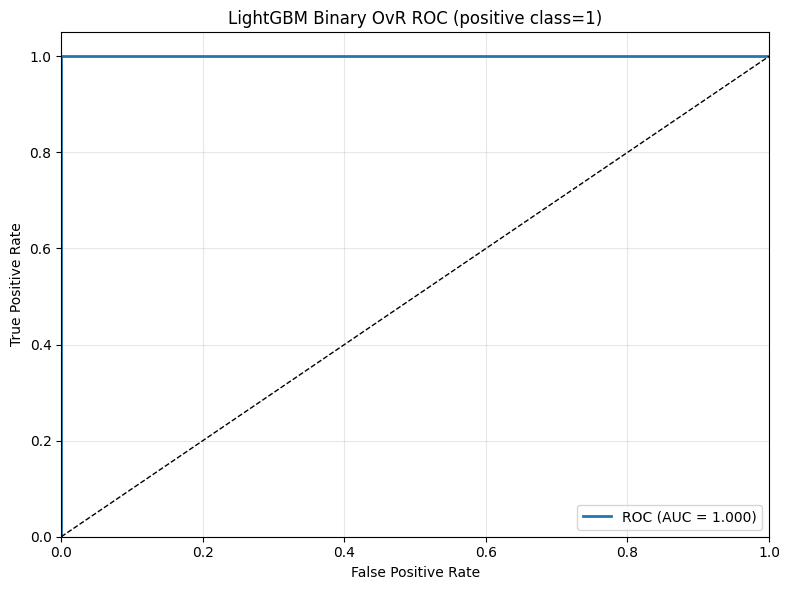

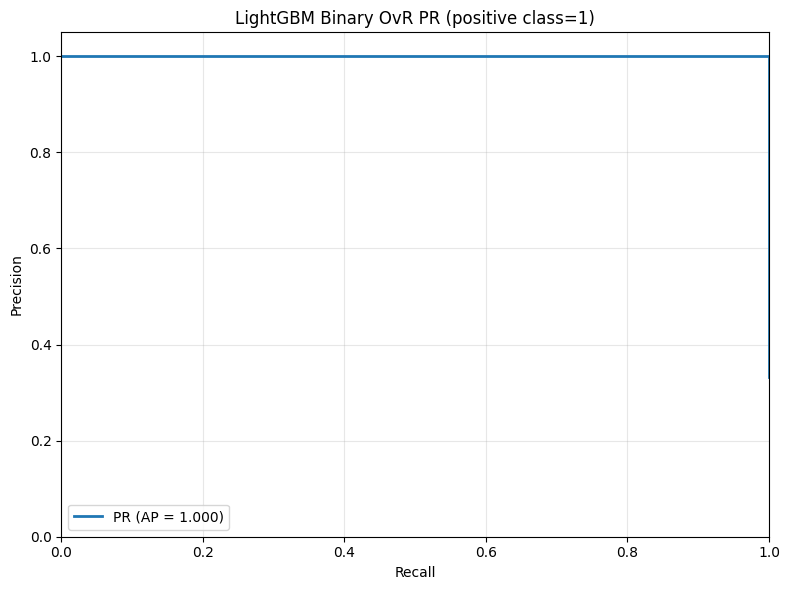


Confusion Matrix (positive class=1):
[[10  0]
 [ 0  5]]

Classification Report (binary OvR):
              precision    recall  f1-score   support

 not class 1       1.00      1.00      1.00        10
     class 1       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [ ]:
# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

# Train model using best iteration from CV
print(f"Training with best_iteration from CV: {best_iteration}")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=best_iteration,
    valid_sets=[lgb_train, lgb_test],
    valid_names=['train', 'valid'],
    callbacks=[lgb.log_evaluation(period=20)]
)
print("✓ Model training complete!")

# Choose positive class for binary one-vs-rest evaluation
positive_class = 1
classes_lgb = np.sort(np.unique(y_train))
if positive_class not in classes_lgb:
    raise ValueError(f"positive_class={positive_class} not found in labels: {classes_lgb}")

# Predict on test set
raw_pred = lgb_model.predict(X_test)

# Build probability for the positive class from different LightGBM output shapes
if np.ndim(raw_pred) == 1:
    # Binary objective often returns probability of positive class directly
    y_lgb_pred_proba = raw_pred.astype(float)
elif np.ndim(raw_pred) == 2:
    if raw_pred.shape[1] == 1:
        y_lgb_pred_proba = raw_pred[:, 0].astype(float)
    elif raw_pred.shape[1] == 2:
        # Binary objective returning [P(class0), P(class1)]
        y_lgb_pred_proba = raw_pred[:, 1].astype(float)
    else:
        # Multiclass output; use OvR probability for selected positive class
        pos_idx = int(np.where(classes_lgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[1]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_lgb_pred_proba = raw_pred[:, pos_idx].astype(float)
else:
    raise ValueError(f"Unexpected prediction shape: {np.shape(raw_pred)}")

# Binary true labels and predictions (positive class vs rest)
y_test_arr = np.asarray(y_test)
y_true_bin = (y_test_arr == positive_class).astype(int)
y_pred_bin = (y_lgb_pred_proba >= 0.5).astype(int)

# Accuracy
test_accuracy_lgb = accuracy_score(y_true_bin, y_pred_bin)
print(f"\nTest set accuracy (OvR, class={positive_class}): {test_accuracy_lgb:.4f}")

# F1 scores
f1_binary = f1_score(y_true_bin, y_pred_bin, average='binary')
f1_macro = f1_score(y_true_bin, y_pred_bin, average='macro')
f1_weighted = f1_score(y_true_bin, y_pred_bin, average='weighted')

print("\nF1 Scores (OvR):")
print(f"  Binary (positive class={positive_class}): {f1_binary:.4f}")
print(f"  Macro-average: {f1_macro:.4f}")
print(f"  Weighted-average: {f1_weighted:.4f}")

# Binary ROC AUC and curve
auc_lgb = roc_auc_score(y_true_bin, y_lgb_pred_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_true_bin, y_lgb_pred_proba)
print("\nBinary ROC AUC (OvR):")
print(f"  AUC: {auc_lgb:.4f}")

# Binary AUPRC and curve
precision_lgb, recall_lgb, _ = precision_recall_curve(y_true_bin, y_lgb_pred_proba)
auprc_lgb = average_precision_score(y_true_bin, y_lgb_pred_proba)
print("\nBinary AUPRC (OvR):")
print(f"  AP: {auprc_lgb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, lw=2, label=f"ROC (AUC = {auc_lgb:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"LightGBM Binary OvR ROC (positive class={positive_class})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_lgb, precision_lgb, lw=2, label=f"PR (AP = {auprc_lgb:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"LightGBM Binary OvR PR (positive class={positive_class})")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix and classification report (binary labels)
print("\n" + "=" * 50)
print(f"Confusion Matrix (positive class={positive_class}):")
print(confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]))

print("\nClassification Report (binary OvR):")
print(classification_report(
    y_true_bin,
    y_pred_bin,
    labels=[0, 1],
    target_names=[f"not class {positive_class}", f"class {positive_class}"],
) )

### Compare with other methods

In [ ]:
# # LightGBM with Information Gain Feature Selection
# # Compute Information Gain (Mutual Information) scores
# print("Computing Information Gain scores for all features...")
# ig_scores = mutual_info_classif(X_processed, y, random_state=42)
# # Create feature ranking
# ig_feature_ranking_lgb = pd.DataFrame({
#     'feature': X_processed.columns,
#     'ig_score': ig_scores
# }).sort_values('ig_score', ascending=False).reset_index(drop=True)

# print(f"\nTop 10 features by Information Gain:")
# print(ig_feature_ranking_lgb.head(10))

# # Evaluate LightGBM performance with different numbers of top IG features
# print("\nEvaluating LightGBM with IG-selected features...")

# # Information Gain
# print("\n" + "=" * 70)
# print("Evaluating with Information Gain feature selection...")

# eval_params = {
#     'max_iter': 1000,
#     'solver': 'lbfgs',
#     'random_state': 42,
#     'n_jobs': 1
# }
# percentages = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]


# ig_perf_table_lr, ig_perf_fig_lr = evaluate_top_features_performance(
#     results_df=ig_feature_ranking_lgb,
#     model_class=LogisticRegression,
#     X_full_train=X_train, X_full_test=X_test,
#     y_train=y_train, y_test=y_test,
#     percentages=percentages, ranking_col='ig_score',
#     model_params=eval_params, log_x=True
# )

# print("\n✓ LightGBM IG-based feature selection analysis complete!")

In [ ]:
# # Feature Selection using LightGBM Feature Importance (Gain)

# print("Training LightGBM to compute feature importance...")

# # Prepare data for LightGBM


# # Create LightGBM datasets
# lgb_train_fi = lgb.Dataset(X_lgb_train, label=y_lgb_train)
# lgb_test_fi = lgb.Dataset(X_lgb_test, label=y_lgb_test, reference=lgb_train_fi)

# # Train LightGBM model to get feature importance
# lgb_model_fi = lgb.train(
#     lgb_params,
#     lgb_train_fi,
#     num_boost_round=100,
#     valid_sets=[lgb_train_fi, lgb_test_fi],
#     valid_names=['train', 'test']
# )

# # Get feature importance (using gain)
# feature_importance_gain = lgb_model_fi.feature_importance(importance_type='gain')
# feature_importance_split = lgb_model_fi.feature_importance(importance_type='split')

# # Create feature importance ranking
# fi_gain_ranking = pd.DataFrame({
#     'feature': X_grouped.columns,
#     'importance_gain': feature_importance_gain,
#     'importance_split': feature_importance_split
# }).sort_values('importance_gain', ascending=False).reset_index(drop=True)

# print(f"\nTop 20 features by LightGBM Feature Importance (Gain):")
# print(fi_gain_ranking.head(20))

# # Select top features based on feature importance
# top_k_fi = 50  # Select top 50 features
# selected_features_fi = fi_gain_ranking.head(top_k_fi)['feature'].tolist()

# print(f"\nSelected {len(selected_features_fi)} features based on feature importance")

# # Evaluate with different numbers of top features
# print("\nEvaluating LightGBM with different numbers of top features...")
# percentages_fi = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]
# fi_results = []

# for pct in percentages_fi:
#     n_features = max(1, int(len(X_grouped.columns) * pct / 100))
#     top_features = fi_gain_ranking.head(n_features)['feature'].tolist()
    
#     # Select features
#     X_fi_train = X_lgb_train[top_features]
#     X_fi_test = X_lgb_test[top_features]
    
#     # Create datasets
#     dtrain_fi = lgb.Dataset(X_fi_train, label=y_lgb_train)
#     dtest_fi = lgb.Dataset(X_fi_test, label=y_lgb_test, reference=dtrain_fi)
    
#     # Train model
#     model_fi = lgb.train(
#         lgb_params,
#         dtrain_fi,
#         num_boost_round=100,
#         valid_sets=[dtest_fi],
#         valid_names=['test'],
#     )
    
#     # Evaluate
#     y_pred_proba = model_fi.predict(X_fi_test)
#     y_pred = np.argmax(y_pred_proba, axis=1)
    
#     accuracy = accuracy_score(y_lgb_test, y_pred)
    
#     fi_results.append({
#         'percentage': pct,
#         'n_features': n_features,
#         'accuracy': accuracy
#     })
    
#     print(f"  {pct}% ({n_features} features): Accuracy = {accuracy:.4f}")

# fi_perf_table = pd.DataFrame(fi_results)

# print("\nRESULTS TABLE (LightGBM Feature Importance-based Selection):")
# print(fi_perf_table.to_string(index=False))

# # Visualize results
# plt.figure(figsize=(10, 6))
# plt.plot(fi_perf_table['n_features'], fi_perf_table['accuracy'], marker='o', linewidth=2)
# plt.xlabel('Number of Features', fontsize=12)
# plt.ylabel('Test Accuracy', fontsize=12)
# plt.title('LightGBM Performance: Feature Importance-based Selection', fontsize=14)
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# print("\n✓ LightGBM Feature Importance-based feature selection analysis complete!")

## XGBoost

In [160]:
seed = 42

xgb_params = {
        'objective': 'multi:softprob', # for multi-class classification
        'num_class': 3, # number of classes for multi-class classification
        'seed':seed, # random seed
        'eval_metric': 'mlogloss',  # multi-class logloss
        'eta': 0.5, # learning rate
        'max_depth': 10,
        'min_child_weight': 0.2,
        'subsample': 0.8, 
        'colsample_bytree': 0.6,
            # Moderate regularization
        "lambda": 3.0,
        "alpha": 0.5,
       }

binary_params = {
    'objective': 'binary:logistic', # for binary classification
    'seed':seed, # random seed
    'eval_metric': 'logloss',  # binary logloss
    'eta': 0.5, # learning rate
    'max_depth': 10,
    'min_child_weight': 0.2,
    'subsample': 0.8, 
    'colsample_bytree': 0.6,
}

### Screening with |SHAP|

In [185]:
X_xgb_train, X_xgb_test, y_xgb_train, y_xgb_test = train_test_split(X_grouped, y, test_size=0.2, random_state=123, stratify=y)
dtrain = xgb.DMatrix(X_xgb_train, label=y_xgb_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_xgb_test,  label=y_xgb_test,  enable_categorical=True)

Training XGBoost model and computing SHAP values for feature ranking...
Train/test split shapes:
  X_train: (57, 3652)
  X_test:  (15, 3652)
✓ Model trained successfully
Computing SHAP values on the training split...
✓ SHAP values computed

Top 20 features by total |SHAP|:
feature  total_abs_shap
 Source      117.845596
   1776       45.269253
     35       33.982487
   2597       28.646067
   3616       27.434597
   2172       20.032522
     34       11.715045
     22        7.785871
   3320        5.831100
   3041        5.033968
   1906        3.783676
    479        3.727938
 Gender        3.086783
   3601        2.697805
   1514        2.013562
   1615        0.000000
     87        0.000000
   1735        0.000000
   2155        0.000000
   1725        0.000000


Evaluating XGBoost performance with SHAP-based feature selection...
✓ 0.01% (1 features): Acc=0.8667, F1=0.8611, AUC(macro)=0.9800
✓ 0.05% (1 features): Acc=0.8667, F1=0.8611, AUC(macro)=0.9800
✓ 0.1% (3 features): Acc=1

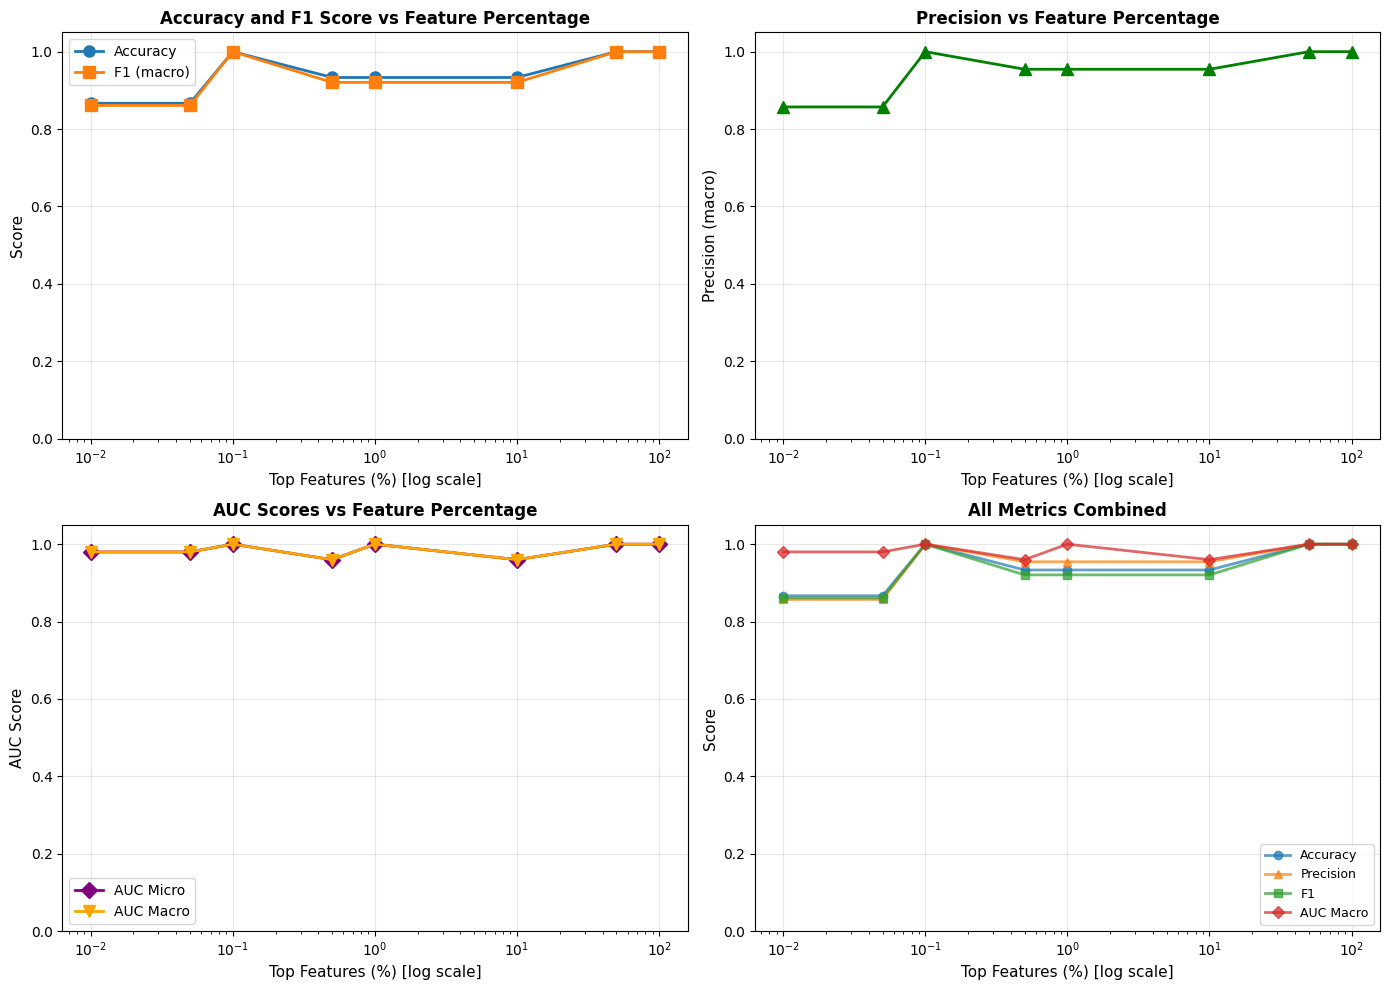


RESULTS TABLE (SHAP-based Feature Selection):
 Percentage  N_Features  Accuracy  Precision (macro)  F1 (macro)  AUC Micro  AUC Macro
       0.01           1  0.866667           0.857143    0.861111       0.98       0.98
       0.05           1  0.866667           0.857143    0.861111       0.98       0.98
       0.10           3  1.000000           1.000000    1.000000       1.00       1.00
       0.50          18  0.933333           0.954545    0.920635       0.96       0.96
       1.00          36  0.933333           0.954545    0.920635       1.00       1.00
      10.00         365  0.933333           0.954545    0.920635       0.96       0.96
      50.00        1826  1.000000           1.000000    1.000000       1.00       1.00
     100.00        3652  1.000000           1.000000    1.000000       1.00       1.00

✓ SHAP-based feature selection analysis complete!


In [186]:
# Train XGBoost model to compute SHAP-based feature rankings without leakage
print("Training XGBoost model and computing SHAP values for feature ranking...")
print("=" * 70)

# Split once, then rank features on the training split only
X_train, X_test, y_train, y_test = train_test_split(
    X_grouped, y, test_size=0.2, random_state=123, stratify=y
)

print("Train/test split shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

classes_xgb = np.sort(np.unique(y_train))
if len(classes_xgb) != 2:
    raise ValueError(f"This ranking cell is configured for binary XGBoost, got classes {classes_xgb}")

xgb_ranking_model = xgb.XGBClassifier(
    **binary_params,
    enable_categorical=True,
 )

# Fit on the training split only to avoid leakage
xgb_ranking_model.fit(X_train, y_train)
print("✓ Model trained successfully")

# Compute SHAP values on the training split only
print("Computing SHAP values on the training split...")
dtrain_rank = xgb.DMatrix(X_train, enable_categorical=True)

# Get SHAP contributions directly from XGBoost (includes bias term as last column)
shap_contribs = xgb_ranking_model.get_booster().predict(
    dtrain_rank,
    pred_contribs=True,
    strict_shape=True,
 )

# Binary XGBoost can return either:
#   (n_samples, n_features + 1)
# or with strict_shape:
#   (n_samples, 1, n_features + 1)
shap_contribs = np.asarray(shap_contribs)
if shap_contribs.ndim == 3:
    shap_values_only = shap_contribs[:, 0, :-1]
elif shap_contribs.ndim == 2:
    shap_values_only = shap_contribs[:, :-1]
else:
    raise ValueError(f"Unexpected SHAP contribution shape for binary XGBoost: {shap_contribs.shape}")

total_abs_shap = np.abs(shap_values_only).sum(axis=0)
print("✓ SHAP values computed")

# Create feature ranking dataframe
shap_feature_ranking = pd.DataFrame({
    "feature": X_train.columns,
    "total_abs_shap": total_abs_shap,
}).sort_values("total_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 20 features by total |SHAP|:")
print(shap_feature_ranking.head(20).to_string(index=False))
print()

# Run performance evaluation using held-out test data
print("\n" + "=" * 70)
print("Evaluating XGBoost performance with SHAP-based feature selection...")
print("=" * 70)

shap_perf_table, shap_perf_fig = evaluate_top_features_performance(
    results_df=shap_feature_ranking,
    model_class=xgb.XGBClassifier,
    X_full_train=X_train,
    X_full_test=X_test,
    y_train=y_train,
    y_test=y_test,
    percentages=[0.01, 0.05, 0.1, 0.5, 1, 10, 50, 100],
    ranking_col="total_abs_shap",
    model_params=binary_params,
    log_x=True,
 )

print("\n" + "=" * 70)
print("RESULTS TABLE (SHAP-based Feature Selection):")
print("=" * 70)
print(shap_perf_table.to_string(index=False))
print("\n✓ SHAP-based feature selection analysis complete!")

In [187]:
X_xgb = X_grouped[shap_feature_ranking['feature'].head(36)]

### Bootstrap

In [188]:
xgb_wrapper = create_model_wrapper(
    "xgboost",
    params=xgb_params,
    num_boost_round=150
)

In [189]:
xgb_boot_results = boot_multi_repeat_inference_keep_all(
    X=X_xgb,  # Use preprocessed data with one-hot encoded categoricals
    y=y,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=2000,  # Fewer bootstraps for speed with MLP
    b_model=1,       # Fewer models per bootstrap
    zero_tol=1e-8,
    params=binary_params,
    n_jobs=6,       
    show_progress=True
)

print(f"\nBootstrap complete! Generated {len(xgb_boot_results)} results.")

Bootstrap repeats: 100%|██████████| 2000/2000 [00:19<00:00, 105.21it/s]


Bootstrap complete! Generated 2000 results.


In [190]:
xgb_mix = estimate_sample_feature_distribution(xgb_boot_results)

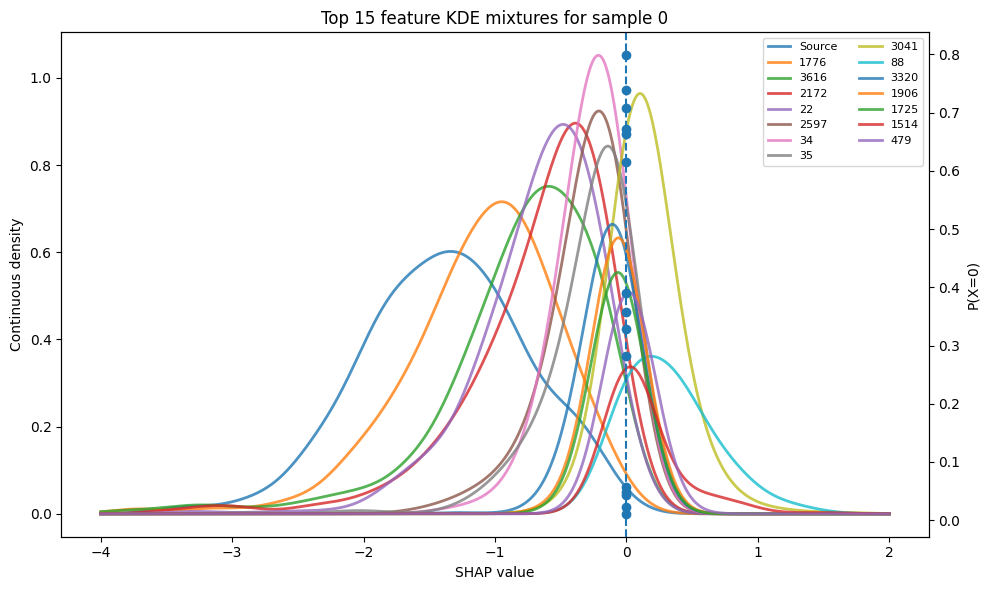

In [191]:
top_df = plot_sample_top_features_overlay(
    mix_df=xgb_mix,
    sample_id=0,
    class_id=None,  # or class index for multiclass
    top_k=15,
    rank_by="mean_abs_estimated",
    n_grid=600,
    xlim=(-4, 2)
)

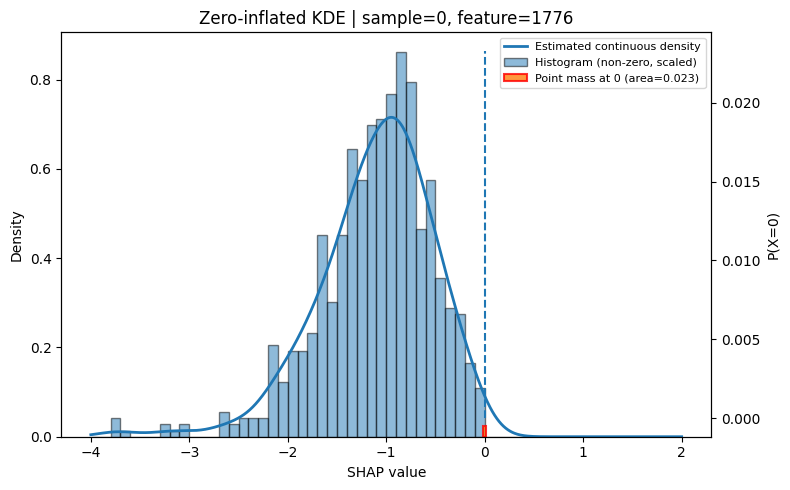

In [193]:
plot_zero_inflated_kde_with_hist(
    mix_df=xgb_mix,
    sample_id=0,
    feature="1776",
    class_id=None,  # or None for binary/regression
    boot_results=xgb_boot_results,  # list[DataFrame] or DataFrame
    bins=60,
    xlim=(-4, 2),
    n_grid=800
)

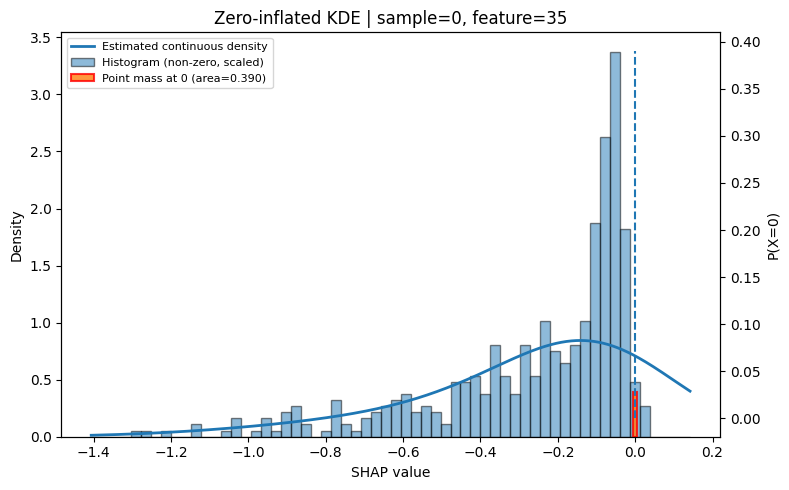

In [194]:
plot_zero_inflated_kde_with_hist(
    mix_df=xgb_mix,
    sample_id=0,
    feature="35",
    class_id=None,  # or None for binary/regression
    boot_results=xgb_boot_results,  # list[DataFrame] or DataFrame
    bins=60,
    n_grid=800
)

In [195]:
xgb_boot_results[0]

,sample_id,feature,shap_value,perm_round,bootstrap_id,boot_random_state
0,2,Source,-1.277888,0,0,0
1,2,1776,-1.355086,0,0,0
2,2,35,-0.046934,0,0,0
3,2,2597,-0.264486,0,0,0
4,2,3616,-0.980244,0,0,0
...,...,...,...,...,...,...
787,69,936,0.000000,0,0,0
788,69,253,0.000000,0,0,0
789,69,3118,0.000000,0,0,0
790,69,722,0.038523,0,0,0


In [196]:
xgb_feature_kde = estimate_feature_level_mixture(
    boot_results=xgb_boot_results,
    kernel="gaussian",
)

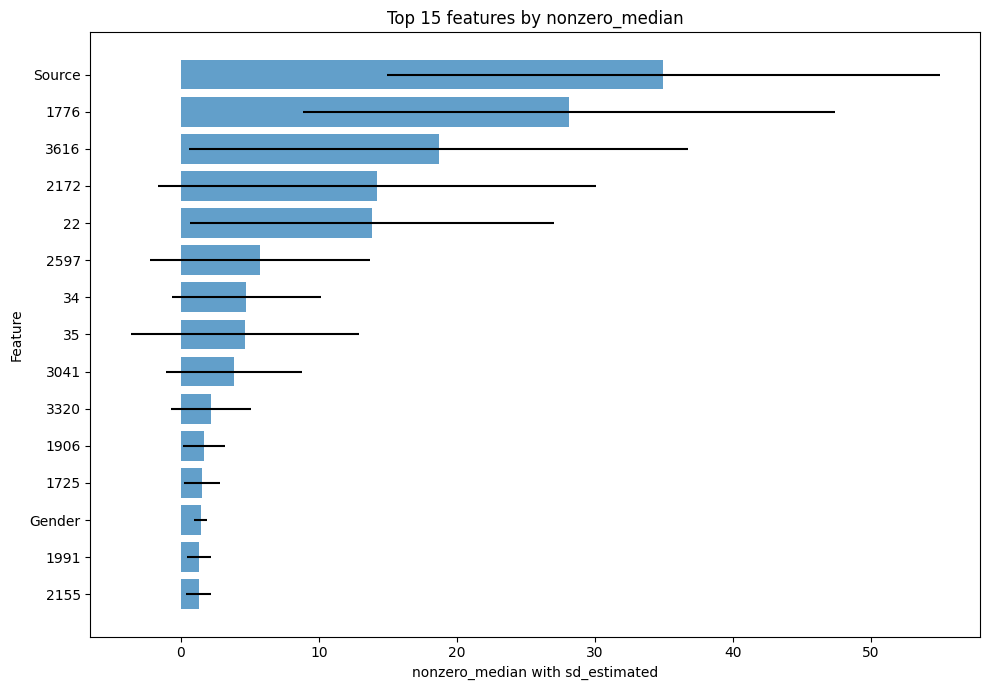

In [197]:
top_with_error = plot_top_feature_with_error(
    xgb_feature_kde,
    top_k=15,
    score_col="nonzero_median",
)

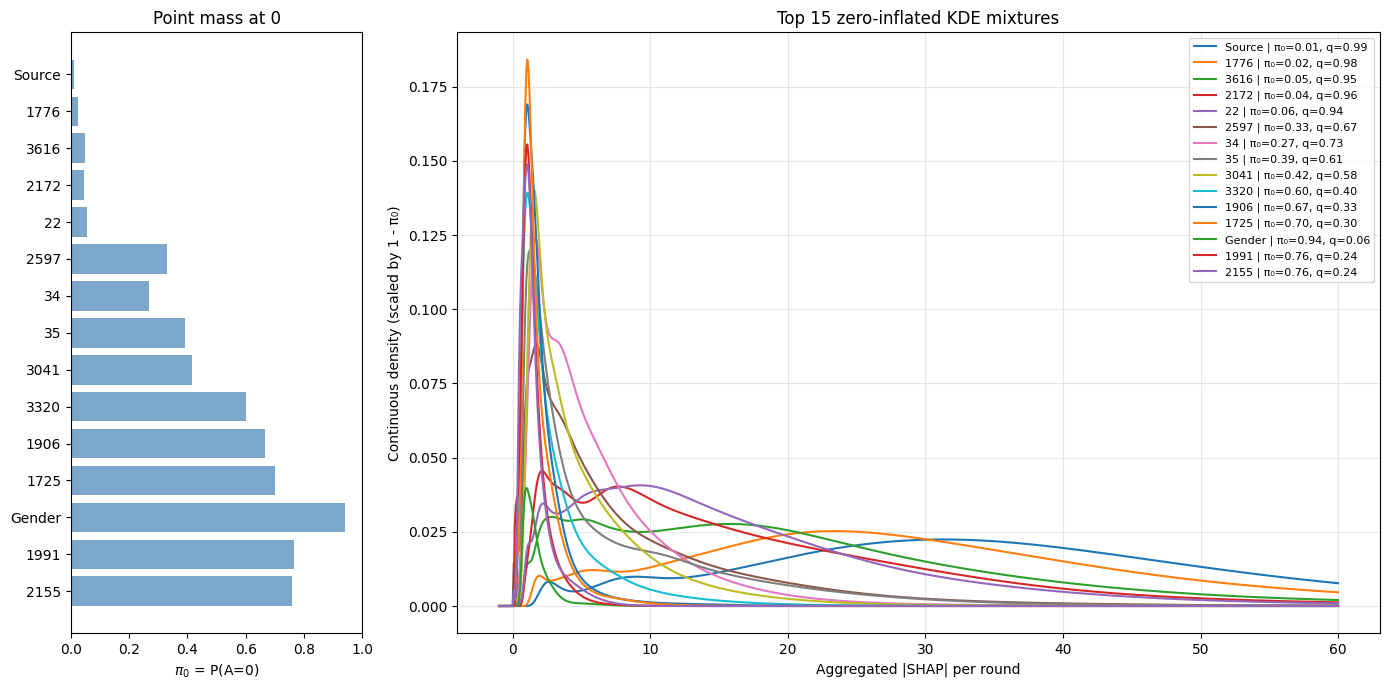

In [199]:
lgb_top = plot_top_feature_density(
    xgb_feature_kde,
    top_k=15,
    score_col="nonzero_median",
    x_min = -1,
    log_x=True,
    x_max=60
)

In [200]:
np.corrcoef(X_grouped['1776'], X_grouped['3616'])[0, 1]

0.6427113513940131

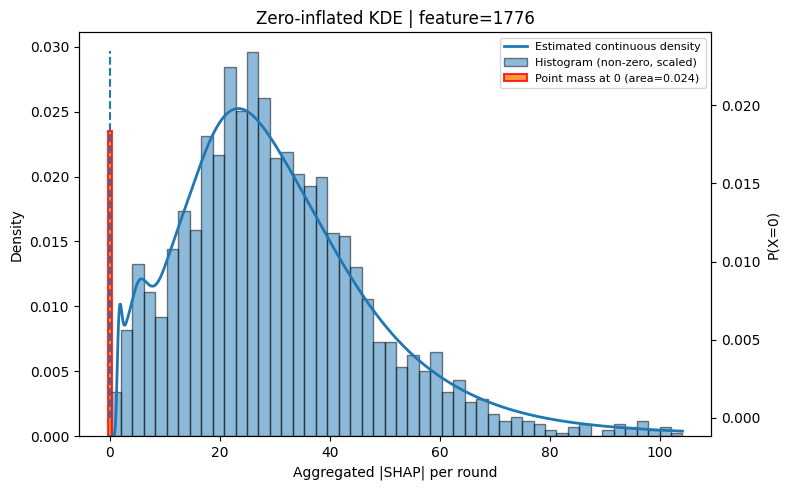

In [201]:
plot_feature_level_kde_with_hist(
    feature_level_df=xgb_feature_kde,
    boot_results=xgb_boot_results,
    feature="1776",
    bins = 50
)

### Feature selection

In [202]:
xgb_feature_kde.head()

,feature,n_bootstrap_rounds,n_total,n_zero,n_nonzero,pi_zero,bandwidth,kernel,zero_tol,kde_model,mean_abs_estimated,mean_estimated,var_estimated,sd_estimated,p_nonzero,peak_density,nonzero_median
0,Source,2000,2000,24,1976,0.0120,0.2,gaussian,0.0,"{'pi_zero': 0.012, 'n_total': 2000, 'n_zero': ...",36.755948,36.755948,400.306932,20.007672,0.9880,0.022422,34.970405
1,1776,2000,2000,47,1953,0.0235,0.2,gaussian,0.0,"{'pi_zero': 0.0235, 'n_total': 2000, 'n_zero':...",30.496188,30.496188,371.344371,19.270298,0.9765,0.025241,28.138583
2,35,2000,2000,782,1218,0.3910,0.2,gaussian,0.0,"{'pi_zero': 0.391, 'n_total': 2000, 'n_zero': ...",5.046064,5.046064,68.332702,8.266360,0.6090,0.118660,4.648295
3,2597,2000,2000,663,1337,0.3315,0.2,gaussian,0.0,"{'pi_zero': 0.3315, 'n_total': 2000, 'n_zero':...",5.808859,5.808859,63.725332,7.982815,0.6685,0.088154,5.755813
4,3616,2000,2000,99,1901,0.0495,0.2,gaussian,0.0,"{'pi_zero': 0.0495, 'n_total': 2000, 'n_zero':...",21.425622,21.425622,327.674540,18.101783,0.9505,0.029988,18.682008


In [209]:
# Keep only unique cluster IDs that pass the threshold
xgb_selected_features = (
    xgb_feature_kde.loc[xgb_feature_kde['pi_zero'] < 0.05, 'feature']
    .astype(str)
    .drop_duplicates()
    .tolist()
)
xgb_selected_features

['Source', '1776', '3616', '2172']

In [210]:
for cluster in xgb_selected_features:
    if isinstance(cluster, str) and cluster.isdigit():
        cluster_id = int(cluster)
    else:
        continue

    genes = cluster_to_genes.get(cluster_id)
    if genes is None:
        continue

    var_exp = cluster_variance_explained.get(cluster_id, np.nan)
    print(f"\nCluster {cluster_id}: {len(genes)} genes, Var explained: {var_exp:.4f}")
    print(f"  Genes: {', '.join(genes[:10])}{'...' if len(genes) > 10 else ''}")


Cluster 1776: 3 genes, Var explained: 0.7968
  Genes: M33680_at, U73737_at, Y08612_at

Cluster 3616: 5 genes, Var explained: 0.7635
  Genes: M92287_at, U94855_at, X15414_at, X59417_at, M31211_s_at

Cluster 2172: 7 genes, Var explained: 0.7691
  Genes: J04027_at, J04990_at, U46751_at, X07743_at, X62654_rna1_at, X90858_at, M13452_s_at


In [212]:
xgb_selected_features = shap_feature_ranking['feature'].head(4).tolist()

In [217]:
X_train, X_test, y_train, y_test = train_test_split(X_grouped[xgb_selected_features], y, test_size=0.2, random_state=123, stratify=y)   

In [218]:
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

In [219]:
# Cross-validation on training data to find optimal parameters
num_rounds = 100  # number of iterations

# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    binary_params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "=" * 50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(
    f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} "
    f"(+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})"
)
print("=" * 50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.34290+0.01508	test-logloss:0.35419+0.05066
[1]	train-logloss:0.22062+0.01320	test-logloss:0.24125+0.04316
[2]	train-logloss:0.15229+0.01415	test-logloss:0.17052+0.04441


[3]	train-logloss:0.10778+0.01105	test-logloss:0.13280+0.05002
[4]	train-logloss:0.08139+0.00638	test-logloss:0.10514+0.03768
[5]	train-logloss:0.06206+0.00438	test-logloss:0.09148+0.04179
[6]	train-logloss:0.04963+0.00393	test-logloss:0.08848+0.04513
[7]	train-logloss:0.04246+0.00382	test-logloss:0.08319+0.04394
[8]	train-logloss:0.03576+0.00296	test-logloss:0.07946+0.03916
[9]	train-logloss:0.03130+0.00312	test-logloss:0.07562+0.04184
[10]	train-logloss:0.02768+0.00331	test-logloss:0.07141+0.04016
[11]	train-logloss:0.02447+0.00309	test-logloss:0.06924+0.03883
[12]	train-logloss:0.02219+0.00271	test-logloss:0.06898+0.03812
[13]	train-logloss:0.02028+0.00264	test-logloss:0.06599+0.03834
[14]	train-logloss:0.01856+0.00238	test-logloss:0.06572+0.03753
[15]	train-logloss:0.01692+0.00218	test-logloss:0.06471+0.03954
[16]	train-logloss:0.01579+0.00202	test-logloss:0.06329+0.03966
[17]	train-logloss:0.01479+0.00205	test-logloss:0.06185+0.03903
[18]	train-logloss:0.01395+0.00163	test-logloss

In [220]:
model = xgb.train(binary_params, dtrain, num_boost_round=best_num_rounds)
y_pred_proba = model.predict(dtest)

y_test_arr = np.asarray(y_test)
classes = np.sort(np.unique(y_train))

# Normalize probabilities to 2D so binary/multiclass paths are handled consistently.
if np.ndim(y_pred_proba) == 1:
    y_score_2d = np.column_stack([1 - y_pred_proba, y_pred_proba])
    y_pred = np.where(y_pred_proba >= 0.5, classes[-1], classes[0])
else:
    y_score_2d = np.asarray(y_pred_proba)
    if y_score_2d.shape[1] == 1:
        p = y_score_2d[:, 0]
        y_score_2d = np.column_stack([1 - p, p])

    pred_idx = np.argmax(y_score_2d, axis=1)
    y_pred = classes[pred_idx] if y_score_2d.shape[1] == len(classes) else pred_idx

# Compact metrics (package-based)
acc = accuracy_score(y_test_arr, y_pred)
print(f"Accuracy: {acc:.4f}")

if len(classes) == 2:
    positive_class = classes[-1]
    y_true_bin = (y_test_arr == positive_class).astype(int)
    auc_score = roc_auc_score(y_true_bin, y_score_2d[:, 1])
    print(f"ROC AUC: {auc_score:.4f}")
else:
    auc_score = roc_auc_score(y_test_arr, y_score_2d, multi_class="ovr", average="macro")
    print(f"ROC AUC (OvR macro): {auc_score:.4f}")

print("\nClassification report:")
print(classification_report(y_test_arr, y_pred, digits=4))

Accuracy: 0.8000
ROC AUC: 0.9600

Classification report:
              precision    recall  f1-score   support

           0     0.8889    0.8000    0.8421        10
           1     0.6667    0.8000    0.7273         5

    accuracy                         0.8000        15
   macro avg     0.7778    0.8000    0.7847        15
weighted avg     0.8148    0.8000    0.8038        15

